# Implementing ANNs with TensorFlow - Homework 04 (Group 4)

## Assignment: MNIST math

###Preparing the MNIST math dataset

In [48]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# load the data
(train_ds, test_ds), ds_info = tfds.load ('mnist', split =['train', 'test'], as_supervised = True, with_info = True)

# only use a subset of the data to accelerate the training process
train_ds = train_ds.take(5000)
test_ds = test_ds.take(500)

###Two MNIST math datasets

In [49]:
def prepare_data(mnist, subtask, batch_size=32):
  """
  This function is used to prepare the raw data for training and testing them with regard to one of two subtasks.
  
  In subtask 1, we want our network to learn whether the predicted values of two images are bigger or equal to 5
  when we add them up.
  In subtask 2, we want the network to predict the result of subtracting the value from one image by another.

  Arguments:
  mnist -- (a subset of) the MNIST dataset
  subtask -- a string denoting the subtask we want to solve (see above)
  batch_size -- denotes the batch size (default is 32)

  Returns a modified data set that includes tuples containing two images and the respective target.
  """
  # flatten the images into vectors
  mnist = mnist.map(lambda img, target: (tf.reshape(img, (-1,)), target))
  # convert images to float32 data type
  mnist = mnist.map(lambda img, target: (tf.cast(img, tf.float32), target))
  # project the pixel values into range [-1, 1]
  mnist = mnist.map(lambda img, target: ((img/128.)-1., target))
  # returns tuples of elements from the MNIST dataset, e.g., ((img1,label1), (img2,label2))
  zipped = tf.data.Dataset.zip((mnist.shuffle(1000), mnist.shuffle(1000)))

  # subtask 1: predict whether a + b >= 5, where a and b are respective MNIST digits
  if subtask == "1":
    # create tuple containing to images and a boolean indicating whether the condition holds
    zipped = zipped.map(lambda img1, img2: (img1[0], img2[0], (img1[1] + img2[1]) >= 5))
    #  transform boolean target to float
    zipped = zipped.map(lambda img1, img2, target: (img1, img2, tf.cast(target, tf.float32)))
  # subtask 2: predict y = a - b
  elif subtask == "2":
    # create tuple containing to images and the result of their subtraction
    zipped = zipped.map(lambda img1, img2: (img1[0], img2[0], img1[1] - img2[1]))
    # represent targets as one-hot vectors (depth of 19 stems from possible value range from -9 to 9)
    zipped = zipped.map(lambda img1, img2, target: (img1, img2, tf.one_hot(target, depth=19)))

  # cache progress into memory
  zipped = zipped.cache()
  # shuffle the data into a random order
  zipped = zipped.shuffle(1000)
  # use batches of size 32
  zipped = zipped.batch(batch_size)
  # prefetch as many data points as we put into a batch
  zipped = zipped.prefetch(tf.data.AUTOTUNE)
  
  return zipped

###Building shared weight models

In [7]:
class MnistMathModel(tf.keras.Model):
  """
  This subclass of the keras model builds our neural network.
  """
  def __init__(self, subtask, optimizer, n_hidden_layers=2, hidden_layer_size=128):
    """
    The constructor initiates the layers and their activation functions.

    Arguments:
    subtask -- a string denoting the subtask we want to solve
    optimizer -- denotes the optimizer we want to use
    n_hidden_layers -- denotes the number of hidden layers (default is 2)
    hidden_layer_size -- denotes the number of neurons in a hidden layer (default is 128)
    """
    # call the parent constructor
    super().__init__()

    # instantiate the hidden layers using ReLU as activation function
    self.hidden_layers = []
    for _ in range(n_hidden_layers):
      self.hidden_layers.append(tf.keras.layers.Dense(hidden_layer_size, activation=tf.nn.relu))

    # instantiate the output layer and loss function depending on the subtask
    if subtask == "1":
      # use sigmoid as activation function to receive a value between 0 and 1
      self.output_layer = tf.keras.layers.Dense(1, activation=tf.nn.sigmoid)
      self.loss_function = tf.keras.losses.BinaryCrossentropy()
      self.model_type = "add"
    elif subtask == "2":
      # use softmax as activation function to get a probability distribution of 19 possible outcomes
      self.output_layer = tf.keras.layers.Dense(19, activation=tf.nn.softmax)
      self.loss_function =  tf.keras.losses.CategoricalCrossentropy()
      self.model_type = "subtract"

    # instantiate the given optimizer
    self.optimizer = optimizer


  @tf.function
  def call(self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- contains the input images
    """
    # extract the two images from the input
    input1, input2 = input

    # feed the first input image through the network
    a = self.hidden_layers[0](input1)
    for layer in self.hidden_layers[1:]:
      a = layer(a)
    # pass the second image through the network
    b = self.hidden_layers[0](input2)
    for layer in self.hidden_layers[1:]:
      b = layer(b)

    # combine the activations and create the output
    output = self.output_layer(tf.concat([a, b], axis = 1)) 

    return output

###Training the networks

In [43]:
def train_step(model, input):
  """
  This function defines a step during the training process.
  Returns the loss and accuracy of a training step.

  Arguments:
  model -- the model object representing our neural network
  input -- the input tensors to the model, also contains the targets as a third component
  """
  input1, input2, target = input
  
  with tf.GradientTape() as tape:
    # create the prediction
    prediction = model((input1, input2))
    # calculate the loss
    loss = model.loss_function(target, prediction)
    # calculate the accuracy depending on the task
    if model.model_type == "add":
      accuracy = np.mean(np.asarray(target) == np.reshape(np.around(prediction),(-1)))
    elif model.model_type == "subtract":
      accuracy = np.mean(np.argmax(target, axis=1) == np.argmax(prediction, axis=1))
  # calculate the gradients
  gradients = tape.gradient(loss, model.trainable_variables)
  # apply the gradients following the optimizer
  model.optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  return loss, accuracy


def test(model, test_data):
  """
  A function to test how the model performs on the given data.
  Returns the mean loss and accuracy.

  Arguments:
  model -- our neural network
  test_data -- the data used for testing
  """
  # lists to track the accuracies and losses
  test_accuracies = []
  test_losses = []
  if model.model_type == "add":
    # iterate over the test data
    for (input1, input2, target) in test_data:
      # create the prediction
      prediction = model((input1, input2), training = False)
      # calculate the loss
      test_loss = model.loss_function(target, prediction)
      # check if the condition holds
      test_accuracy = np.asarray(target) == np.reshape(np.around(prediction),(-1))
      # calculate the mean accuracy
      test_accuracy = np.mean(test_accuracy)
      # store loss and accuracy
      test_losses.append(test_loss.numpy())
      test_accuracies.append(np.mean(test_accuracy))
  elif model.model_type == "subtract":
    # iterater over the test data
    for (input1, input2, target) in test_data:
      # create the prediction
      prediction = model((input1, input2), training = False)
      # calculate the loss
      test_loss = model.loss_function(target, prediction)
      # check if prediction matches the target
      test_accuracy = np.argmax(target, axis=1) == np.argmax(prediction, axis=1)
      # calculate the mean accuracy
      test_accuracy = np.mean(test_accuracy)
      # store loss and accuracy
      test_losses.append(test_loss.numpy())
      test_accuracies.append(np.mean(test_accuracy))

  # calculate the mean losses and accuracy
  test_loss = tf.reduce_mean(test_losses)
  test_accuracy = tf.reduce_mean(test_accuracies)

  return test_loss, test_accuracy


def training(subtask, n_epochs, optimizer):
  """
  Defines the training process of our neural network.
  Returns the training losses and accuracies.

  Arguments:
  model -- the model object representing our neural network
  n_epochs -- the number of training steps
  optimizer -- denotes the model optimizer
  """
  model = MnistMathModel(subtask, optimizer)

  train_data = prepare_data(train_ds, subtask)
  test_data = prepare_data(test_ds, subtask)

  # lists to track training/test losses and accuracies
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # train for given number of epochs
  for epoch in range(n_epochs):
    # lists to track losses and accuracies
    epoch_losses = []
    epoch_accuracies = []

    # iterate over all images in the data set
    for input in train_data:
      # update the network and record loss and accuracy
      train_loss, train_accuracy = train_step(model, input)
      epoch_losses.append(train_loss)
      epoch_accuracies.append(train_accuracy)

    # calculate the mean loss and accuracy
    train_losses.append(tf.reduce_mean(epoch_losses))
    train_accuracies.append(tf.reduce_mean(epoch_accuracies))
    
    # track loss and accuracy on the test data
    test_loss, test_accuracy = test(model, test_data)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    #print("Epoch: ", epoch, "Loss: ", np.asarray(tf.reduce_mean(epoch_losses)), "Accuracy: ", np.asarray(test_accuracy))

  return train_losses, train_accuracies, test_losses, test_accuracies

In [51]:
def visualization(ax, train_losses, train_accuracies, test_losses, test_accuracies, optimizer_name):
  """
  This function visualizes the training progress by showing the mean losses and accuracies after each epoch.

  Arguments:
  ax -- denotes the axes to plot on 
  train_losses -- recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  optimizer_name -- the name of the model optimizer
  """
  # plot training and test losses and accuracies
  line1, = ax.plot(train_losses, color="orange", linestyle="-")
  line2, = ax.plot(test_losses, color="green", linestyle="-")
  line3, = ax.plot(train_accuracies, color="orange", linestyle="--")
  line4, = ax.plot(test_accuracies, color="green", linestyle="--")
  # create the title
  ax.set_title(optimizer_name)
  # create the legend
  ax.legend((line1, line2, line3, line4), ("Training loss","Test loss", "Training accuracy", "Test accuracy"))

###Experiments

In [57]:
# hyperparameter for the training process
num_epochs = 10

# the optimizers we want to test
optimizers = [["SGD", tf.keras.optimizers.SGD()], 
              ["SGD with 0.3 momentum", tf.keras.optimizers.SGD(momentum=0.3)],
              ["SGD with 0.6 momentum", tf.keras.optimizers.SGD(momentum=0.6)],
              ["RMSProp", tf.keras.optimizers.RMSprop()],
              ["AdaGrad", tf.keras.optimizers.Adagrad()],
              ["Adam", tf.keras.optimizers.Adam()]]

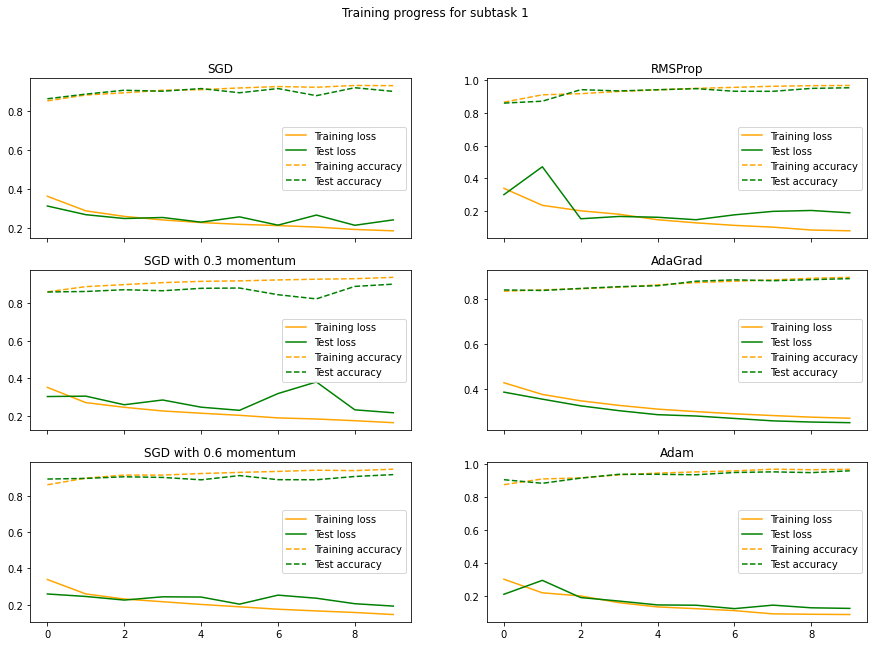

In [58]:
# create the plot grid
fig, axes = plt.subplots(nrows=3, ncols=2, sharex=True, figsize=(15,10))
# give it a proper title
fig.suptitle("Training progress for subtask 1")

# train the model and visualize the results for subtask 1
for i, optimizer in enumerate(optimizers):
  train_losses, train_accuracies, test_losses, test_accuracies = training(subtask="1", n_epochs=num_epochs, optimizer=optimizer[1])
  visualization(axes[i % 3, 0 if i < 3 else 1], train_losses, train_accuracies, test_losses, test_accuracies, optimizer[0])

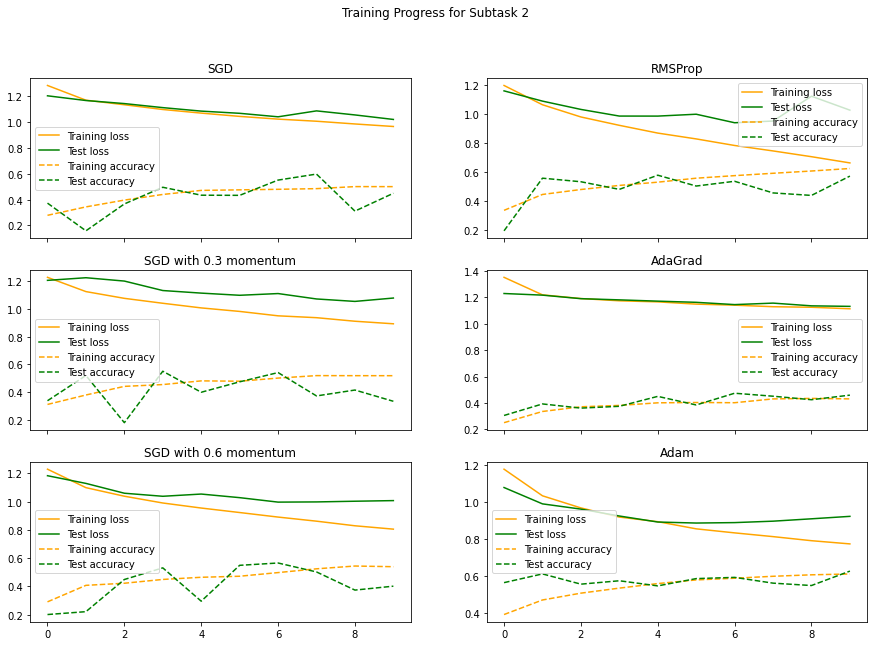

In [59]:
fig, axes = plt.subplots(nrows=3, ncols=2, sharex=True, figsize=(15,10))

fig.suptitle("Training Progress for Subtask 2")

# train the model and visualize the results for subtask 2
for i, optimizer in enumerate(optimizers):
  train_losses, train_accuracies, test_losses, test_accuracies = training(subtask="2", n_epochs=num_epochs, optimizer=optimizer[1])
  visualization(axes[i % 3, 0 if i < 3 else 1], train_losses, train_accuracies, test_losses, test_accuracies, optimizer[0])